In [1]:
# Import the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix.csv')

In [3]:
print("The Shape of the Data:", df.shape)

The Shape of the Data: (8807, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Check the null values

In [5]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


# Common issues in this dataset include:

- Missing values in columns like director, cast, country, date_added, rating, and duration.
- No duplicates typically, but always check.
- Multi-value fields (e.g., multiple countries or genres) stored as comma-separated strings.
- date_added is a string that should be parsed into a datetime object.
- release_year might need confirmation as integer.

In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
# Check for duplicates

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [8]:
total_null_values = df.isnull().sum().sum()
print(f"Total number of Null Values in Netflix Dataset: {total_null_values}")

Total number of Null Values in Netflix Dataset: 4307


In [9]:
# Count missing values per column

missing = df.isnull().sum()
print("Missing Values:\n", missing[missing > 0])

Missing Values:
 director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [10]:
# Percentage of missing values:
missing_percetage = (df.isnull().sum() / len(df)) * 100
print("Missing Data Percentage:\n", missing_percetage[missing_percetage > 0])


Missing Data Percentage:
 director      29.908028
cast           9.367549
country        9.435676
date_added     0.113546
rating         0.045418
duration       0.034064
dtype: float64


Explanation: Common missing: director (~30%), cast (~9%), country (~9%), date_added (~0.1%), rating (~0.05%), duration (~0.03%). No missing in show_id, type, title, etc.

In [11]:
# Fill missing categorical values with 'Unknown'

df.director.fillna('Unknown', inplace=True)
df.cast.fillna('Unknown', inplace=True)
df.country.fillna('Other', inplace=True)
df.rating.fillna('Unknown', inplace=True)
df.duration.fillna('Unknown', inplace=True)

In [12]:
missing = df.isnull().sum()
print("Missing Values:\n", missing[missing > 0])

Missing Values:
 date_added    10
dtype: int64


In [13]:
# Drop rows with missing 'date_added' (few rows)

df.dropna(subset=['date_added'], inplace=True)

# Verify not missing left in key columns

print("Missing data after cleaning:\n", df.isnull().sum())

Missing data after cleaning:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


# Explanation:

- Used 'Unknown' for optional fields like director/cast to avoid losing rows.
- Droped for date_added since it's rare and important for time-based analysis.
- Avoid dropping too much data at basic level.

# Convert Data Types

Fix formats for analysis.

In [14]:
# Convert 'date_added' to datetime

df.date_added = pd.to_datetime(df.date_added.str.strip(), format="%B, %d, %Y", errors='coerce')

df.release_year = df.release_year.astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    0 non-null      datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   duration      8797 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 893.4+ KB


Explanation: date_added comes as strings like "September 25, 2021". Converting allows date operations. If errors, 'coerce' sets invalid to NaT (handle if needed).

# Clean and Transform Columns:
Basic transformations for multi-value fields.

In [15]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [16]:
# Split 'listed_in' into a list of genres (for easier analysis)
df['genres'] = df['listed_in'].str.split(',')

# Example: Extract primary country (first one if multiple)
df['primary_country'] = df['country'].str.split(',').str[0]

# For duration: Separate movies and TV shows
df['duration_numeric'] = df['duration'].str.extract('(\\d+)', expand=False).astype(float)
df['unit'] = df['duration'].str.extract('([a-zA-Z]+)', expand=False)

# Drop original 'duration' if not needed
df.drop('duration', axis=1, inplace=True)  # Optional


#View Changes
df[['listed_in', 'genres', 'country', 'primary_country', 'duration_numeric', 'unit']].head()

,listed_in,genres,country,primary_country,duration_numeric,unit
0,Documentaries,[Documentaries],United States,United States,90.0,min
1,"International TV Shows, TV Dramas, TV Mysteries","[International TV Shows, TV Dramas, TV Myste...",South Africa,South Africa,2.0,Seasons
2,"Crime TV Shows, International TV Shows, TV Act...","[Crime TV Shows, International TV Shows, TV ...",Other,Other,1.0,Season
3,"Docuseries, Reality TV","[Docuseries, Reality TV]",Other,Other,1.0,Season
4,"International TV Shows, Romantic TV Shows, TV ...","[International TV Shows, Romantic TV Shows, ...",India,India,2.0,Seasons


Explanation:

Splitting makes genres/countries queryable (e.g., count occurrences).
Extract numbers from duration for numerical analysis (e.g., movie length in minutes).
This prepares for filtering, e.g., movies over 2 hours.

# Remove Duplicates (If Any)
Though rare, always check.

In [17]:
# Drop duplicates based on 'title' and 'type' (unique identifiers)

df.drop_duplicates(subset=['title', 'type'], inplace=True)
print(f"Shape after dropping duplicates:", {df.shape})


Shape after dropping duplicates: {(8797, 15)}


Basic Verification with summery or plot:

In [18]:
# Summary of types:
print(df.type.value_counts())

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [19]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'listed_in', 'description', 'genres',
       'primary_country', 'duration_numeric', 'unit'],
      dtype='object')

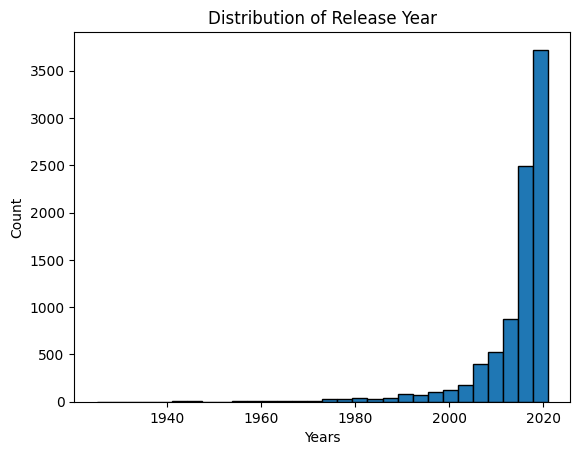

In [20]:
# Optional: Plot release years (requires matplotlib)

df.release_year.hist(bins=30, edgecolor='k')
plt.title("Distribution of Release Year")
plt.xlabel('Years')
plt.ylabel('Count')
plt.grid(False)
plt.show()

Explanation: Expect more 'Movie' than 'TV Show'. Histogram shows peak in recent years.

Basic Distributions

Count by type (Movie vs TV Show)

Years of release — how many titles per release_year

Ratings — distribution (PG/R, etc.)

Countries — top countries producing Netflix content

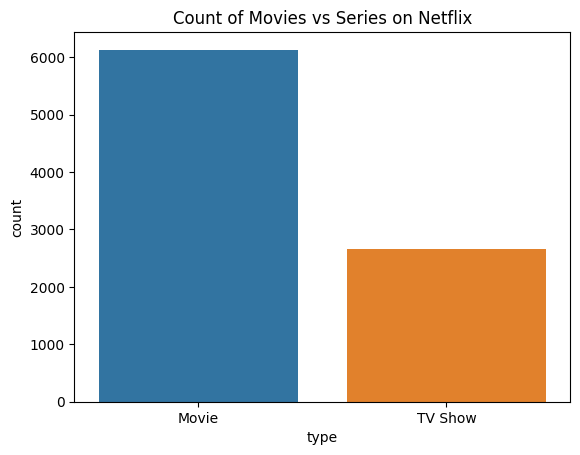

In [24]:
# Movies vs TV Shows

sns.countplot(data=df, x='type', hue='type')
plt.title('Count of Movies vs Series on Netflix')
plt.show()

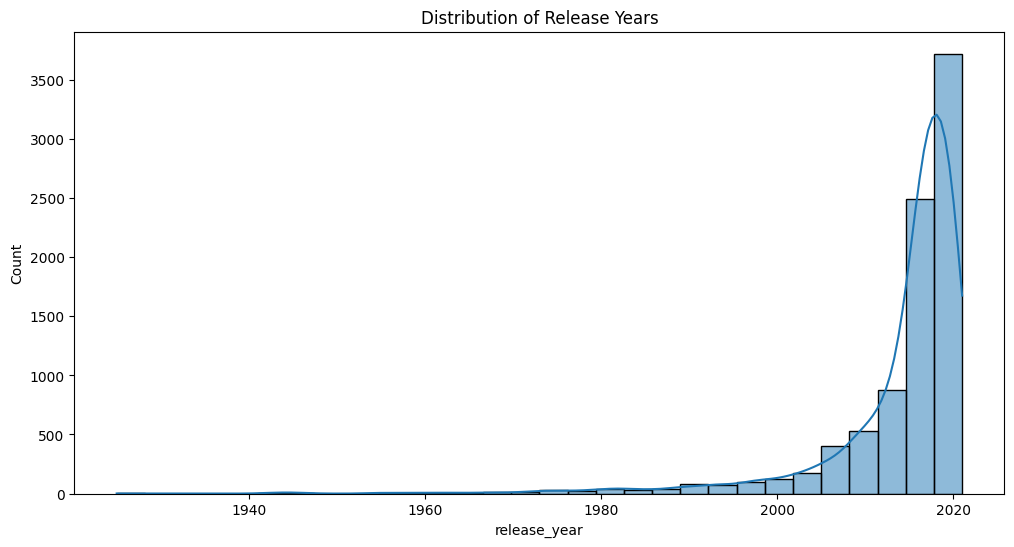

In [28]:
# Release year distribution

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='release_year', bins=30, kde=True)
plt.title("Distribution of Release Years")
plt.show()

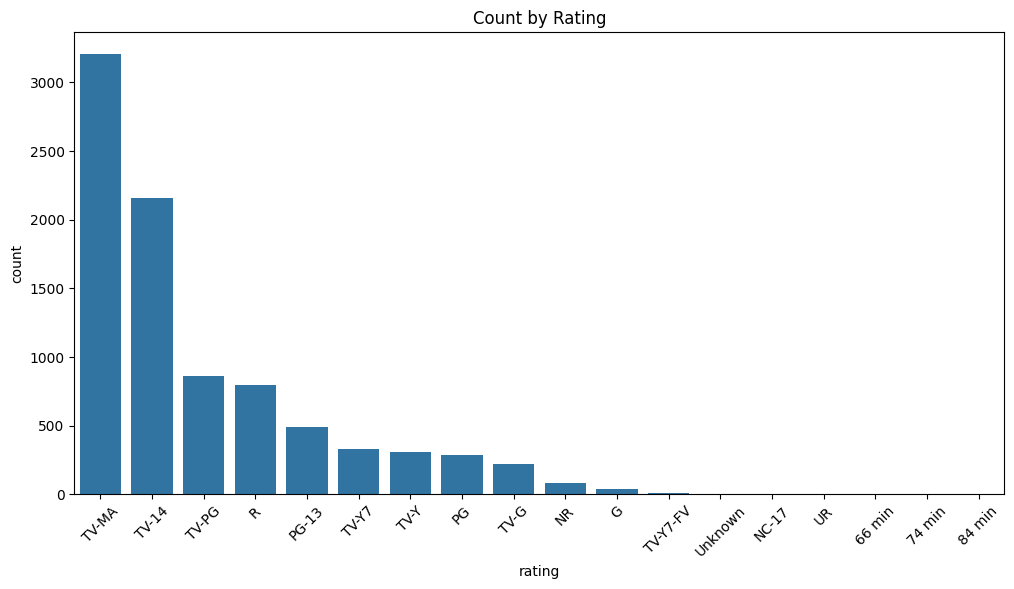

In [32]:
# Ratings
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', order=df.rating.value_counts().index)
plt.xticks(rotation=45)
plt.title("Count by Rating")
plt.show()

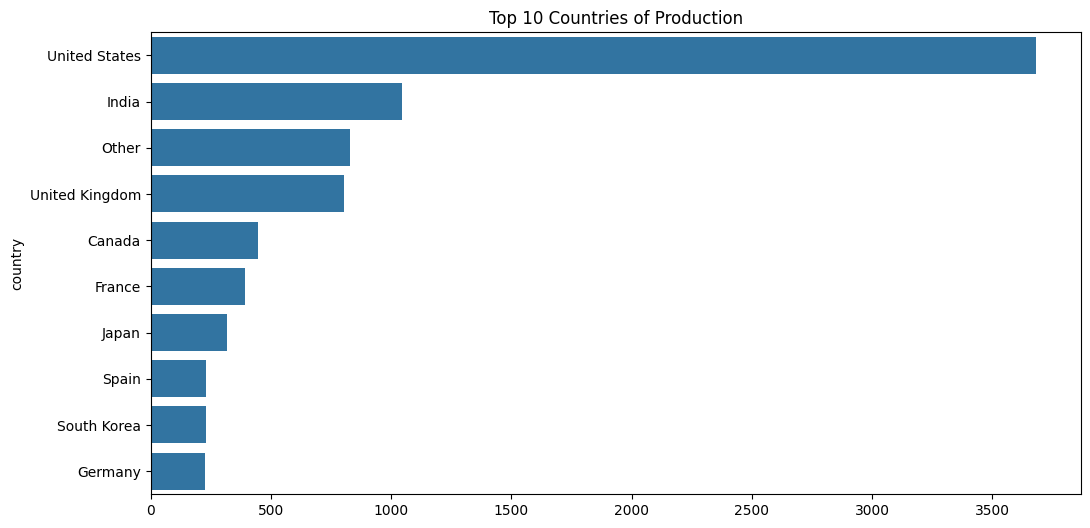

In [36]:
# top counties (top 10)

country_counts = df.country.dropna().str.split(", ").explode().value_counts().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title("Top 10 Countries of Production")
plt.show()


Relationships / Deeper Insights

Does Netflix favour newer content? Plot mean release year by type

Duration vs Type: compare movie durations vs number of seasons for TV shows

Time added vs release date: sometimes date_added is much later than release_year

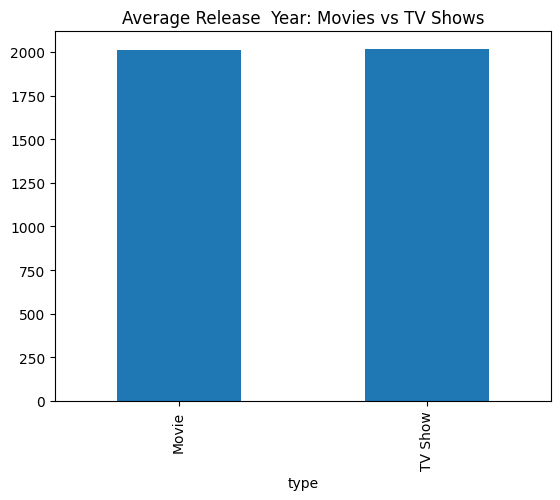

In [38]:
# Mean release year by type
df.groupby('type')['release_year'].mean().plot(kind='bar')
plt.title("Average Release  Year: Movies vs TV Shows")
plt.show()

# Summary / Takeaways

After doing this you might observe things like:

- Many missing values in director, cast, country etc.

- More content in recent years vs older years

- Movies vs TV Shows have different patterns (TV shows have “seasons” instead of “duration in minutes”)

- Some weird durations or missing durations etc.